Lo primero de todo, instalamos e importamos librerías

In [48]:
%pip install seaborn
%pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import sys
sys.path.append('../')
from src import sp_eda as se
pd.set_option('display.max_columns', None)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Configuramos los graficos que se presentan

In [49]:
sns.set(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)

Cargamos el dataset, y refrescamos el analisis preliminar

In [50]:
df = pd.read_csv("../data/Acc_met_clean.csv")
se.eda_prelim(df)
df.sample(5)

----------
DIMENSIONES
El conjunto de datos presenta 17653 filas y 21 columnas
----------
INFORMACION DE COLUMNAS
<class 'pandas.DataFrame'>
RangeIndex: 17653 entries, 0 to 17652
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   STATE_CODE         17653 non-null  str  
 1   STATE              17653 non-null  str  
 2   DATE               17653 non-null  str  
 3   ACC_EVENTS         17653 non-null  int64
 4   ACC_SEV_LIGHT      17653 non-null  int64
 5   ACC_SEV_MODERATE   17653 non-null  int64
 6   ACC_SEV_HEAVY      17653 non-null  int64
 7   ACC_SEV_SEVERE     17653 non-null  int64
 8   WEATHER_EVENTS     17653 non-null  int64
 9   TYP_COLD           17653 non-null  int64
 10  TYP_FOG            17653 non-null  int64
 11  TYP_HAIL           17653 non-null  int64
 12  TYP_PRECIPITATION  17653 non-null  int64
 13  TYP_RAIN           17653 non-null  int64
 14  TYP_SNOW           17653 non-null  int64
 15  T

,STATE_CODE,STATE,DATE,ACC_EVENTS,ACC_SEV_LIGHT,ACC_SEV_MODERATE,ACC_SEV_HEAVY,ACC_SEV_SEVERE,WEATHER_EVENTS,TYP_COLD,TYP_FOG,TYP_HAIL,TYP_PRECIPITATION,TYP_RAIN,TYP_SNOW,TYP_STORM,WEA_SEV_LIGHT,WEA_SEV_MODERATE,WEA_SEV_HEAVY,WEA_SEV_SEVERE,WEA_SEV_UNKNOWN
13675,RI,Rhode Island,2022-11-27,0,0,0,0,0,19,0,0,0,0,19,0,0,13,6,0,0,0
3533,GA,Georgia,2022-11-04,59,0,55,0,4,46,0,42,0,0,4,0,0,4,8,0,34,0
15714,VA,Virginia,2022-08-11,314,30,249,20,15,180,7,8,0,8,157,0,0,130,22,5,15,8
11763,NY,New York,2022-08-10,240,1,226,12,1,16,2,10,0,0,4,0,0,3,1,0,12,0
8101,MO,Missouri,2022-06-16,49,3,34,12,0,26,1,18,0,0,7,0,0,7,11,0,8,0


### 1. Correlación general entre el número de accidentes y el número de eventos climatológicos.

Preparamos un grafico de dispersión Accidentes-Eventos climatológicos.

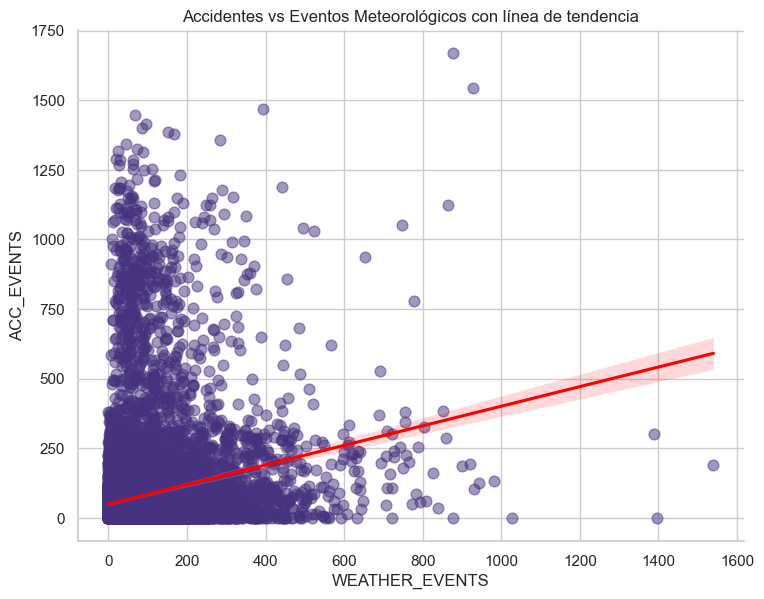

In [51]:
sns.lmplot(
    data=df,
    x="WEATHER_EVENTS",
    y="ACC_EVENTS",
    height=6,
    aspect=1.3,
    scatter_kws={"alpha":0.5, "s":60},
    line_kws={"color":"red"}
)
plt.title("Accidentes vs Eventos Meteorológicos con línea de tendencia")
plt.show()


La linea de tendencia es positiva pero con una correlación débil. 

Preparamos la matriz de correlaciones.

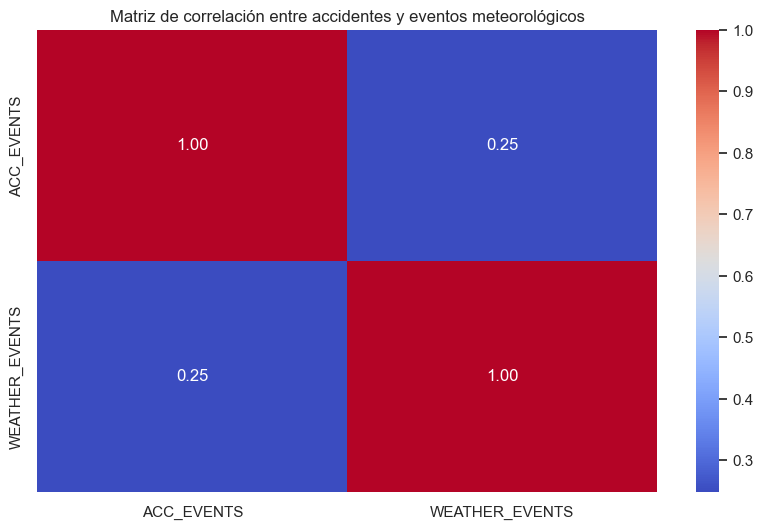

In [52]:
variables_corr = [
    "ACC_EVENTS",
    "WEATHER_EVENTS"
]

corr = df[variables_corr].corr(method="spearman")

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre accidentes y eventos meteorológicos")
plt.show()

Para evaluar la relación entre el número de accidentes y el número de eventos meteorológicos se utiliza la correlación de Spearman, ya que ambas variables son conteos discretos, no siguen una distribución normal y presentan una relación no lineal. Spearman muestra una correlación positiva débil (0.25), lo que indica que, aunque los accidentes tienden a aumentar ligeramente cuando aumentan los eventos meteorológicos, esta relación no es fuerte ni consistente. Esto coincide con el gráfico de dispersión, donde se observa una tendencia ascendente pero con alta dispersión.

### 2. Analisis del impacto por el tipo de evento climatológico.

Para ello calculamos medias de accidentes con o sin cada evento meteorológico.

In [53]:
event_types = [
    "TYP_COLD",
    "TYP_FOG",
    "TYP_HAIL",
    "TYP_PRECIPITATION",
    "TYP_RAIN",
    "TYP_SNOW",
    "TYP_STORM"
]

impact = {}

for col in event_types:
    impact[col] = df.groupby(df[col] > 0)["ACC_EVENTS"].mean()

Convertimos el diccionario en un df, renombramos "sin evento" y "con evento", y calculamos el incremento procentual. Mostramos la tabla.

In [54]:
impact_df = pd.DataFrame(impact).T
impact_df.columns = ["Sin evento", "Con evento"]
impact_df["Incremento %"] = ((impact_df["Con evento"] - impact_df["Sin evento"]) / impact_df["Sin evento"]) * 100

print("\nImpacto por tipo de evento:")
print(impact_df)


Impacto por tipo de evento:
                   Sin evento  Con evento  Incremento %
TYP_COLD            40.881315  104.162387    154.792167
TYP_FOG             27.403429   82.872465    202.416411
TYP_HAIL            71.719437   99.424242     38.629424
TYP_PRECIPITATION   62.051115  103.798267     67.278649
TYP_RAIN            42.843455   82.947570     93.606165
TYP_SNOW            76.339035   59.481925    -22.081901
TYP_STORM           68.142690   97.076856     42.461144


Presentamos gráfico con incrementos

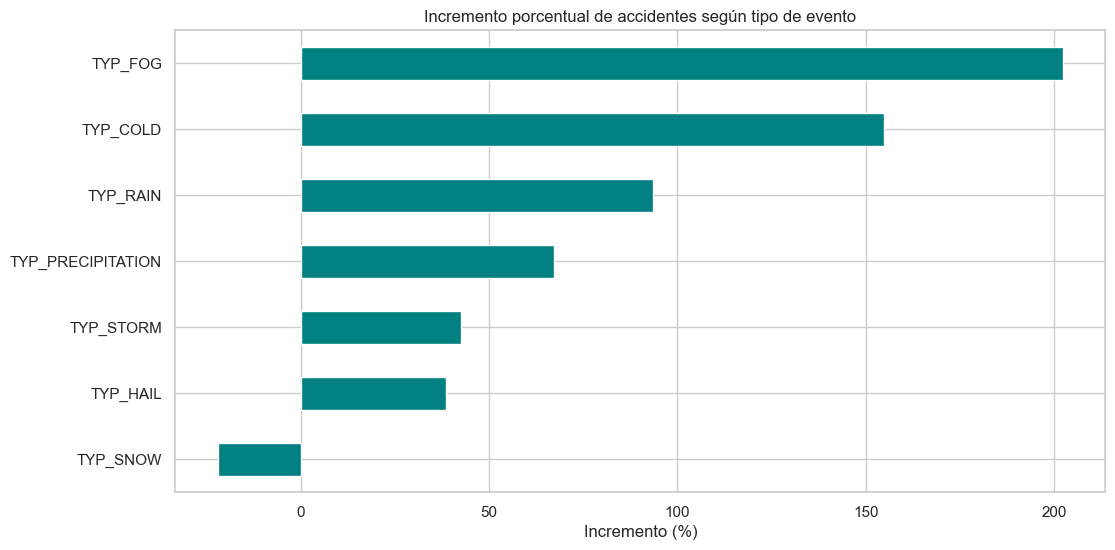

In [55]:
impact_df["Incremento %"].sort_values().plot(kind="barh", color="teal")
plt.title("Incremento porcentual de accidentes según tipo de evento")
plt.xlabel("Incremento (%)")
plt.show()

Los días con niebla y frío el número de accidentes se incrementa un 202% y un 155% respectivamente. Por el contrario, y a pesar de lo que podría parecer, los días con nieve se reducen un 22 % 

### 3. Impacto por severidad del evento.

Vamos a estudiar las correlaciones entre la severidad del evento climatológico y el número de accidentes.

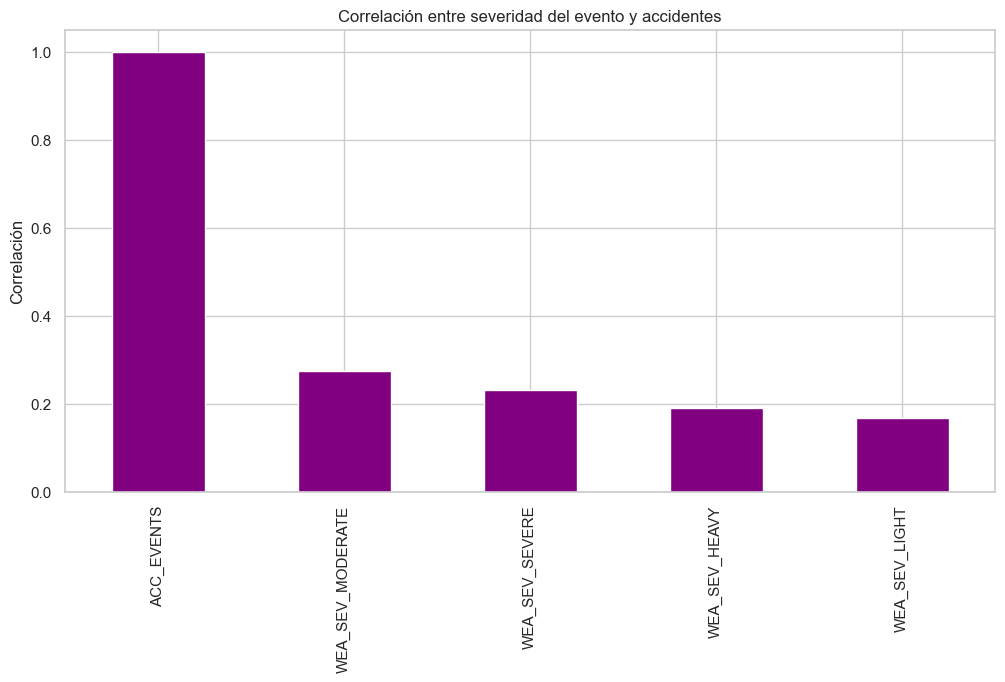

In [56]:
severity_cols = ["WEA_SEV_LIGHT", "WEA_SEV_MODERATE", "WEA_SEV_HEAVY", "WEA_SEV_SEVERE"]

severity_impact = df[["ACC_EVENTS"] + severity_cols].corr(method="spearman")["ACC_EVENTS"].sort_values(ascending=False)

severity_impact.plot(kind="bar", color="purple")
plt.title("Correlación entre severidad del evento y accidentes")
plt.ylabel("Correlación")
plt.show()

### 4. Relación entre severidad del accidente y eventos climatologicos severos.

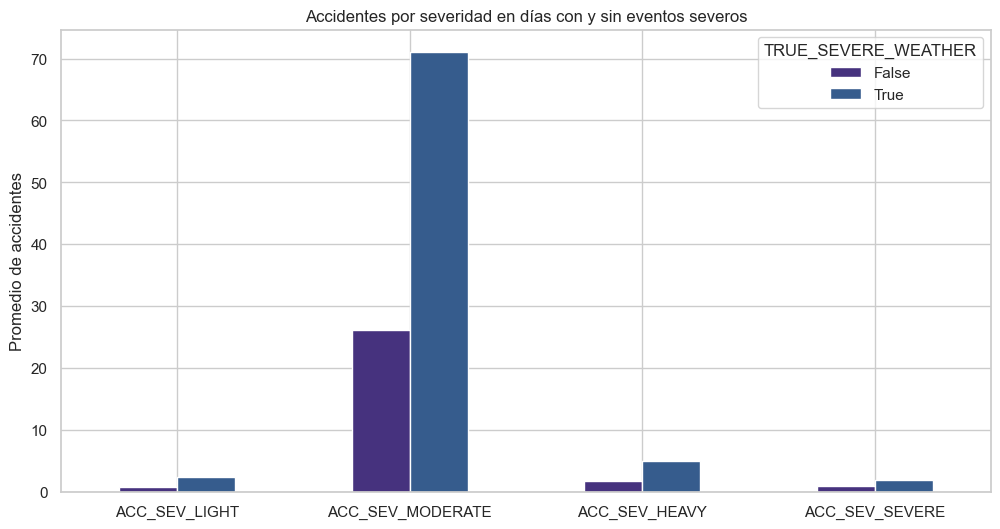

In [57]:
acc_severity_cols = ["ACC_SEV_LIGHT", "ACC_SEV_MODERATE", "ACC_SEV_HEAVY", "ACC_SEV_SEVERE"]

df["TRUE_SEVERE_WEATHER"] = df["WEA_SEV_SEVERE"] > 0

severity_comparison = df.groupby("TRUE_SEVERE_WEATHER")[acc_severity_cols].mean()

severity_comparison.T.plot(kind="bar", figsize=(12, 6))
plt.title("Accidentes por severidad en días con y sin eventos severos")
plt.ylabel("Promedio de accidentes")
plt.xticks(rotation=0)
plt.show()


Los eventos climatologicos severos, incrementan en general el número de accidentes, siendo los accidentes moderados los que llaman más la atención por el numero de eventos iniciales.
Lo vemos a nivel porcentual

In [58]:
sev = severity_comparison.T
sev["Incremento %"] = ((sev[True] - sev[False]) / sev[False]) * 100

print(sev)

TRUE_SEVERE_WEATHER      False       True  Incremento %
ACC_SEV_LIGHT         0.697485   2.435117    249.128313
ACC_SEV_MODERATE     26.193406  71.117735    171.510072
ACC_SEV_HEAVY         1.779062   4.943444    177.868004
ACC_SEV_SEVERE        0.841944   1.850520    119.791276


Observamos que se produce mayor incremento porcentual de los accidentes leves y graves, pero el peso sobre la muestra es más pequeño por lo que a simple vista sobre el gráfico no llama la atención y si el de accidentes moderados.

### 5. Análisis temporal de accidentes y eventos meteorológicos

Vamos a representar el numero de accidentes y eventos meteorológicos promedio por mes 

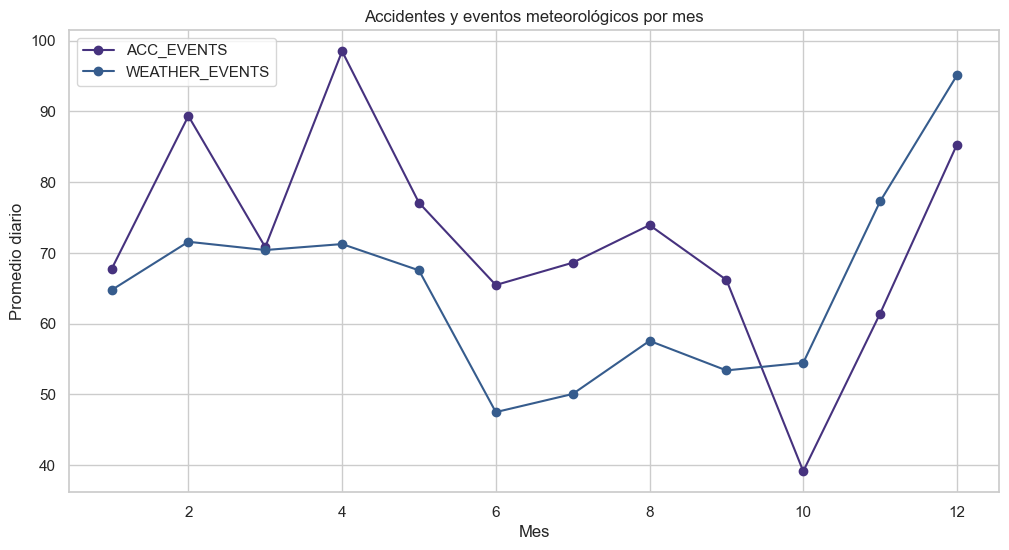

In [59]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["MONTH"] = df["DATE"].dt.month

monthly = df.groupby("MONTH")[["ACC_EVENTS", "WEATHER_EVENTS"]].mean()
monthly.plot(marker="o")
plt.title("Accidentes y eventos meteorológicos por mes")
plt.xlabel("Mes")
plt.ylabel("Promedio diario")
plt.show()

Aunque las líneas mensuales de accidentes y eventos meteorológicos muestran patrones estacionales similares, la correlación entre ambas variables es baja. Esto ocurre porque la correlación se calcula punto a punto (día a día), donde existe una gran variabilidad: muchos días con accidentes altos y clima bajo, y otros con clima alto y pocos accidentes. Al agrupar los datos por mes, el ruido diario desaparece y emergen tendencias generales que pueden parecer paralelas, pero esto no implica una relación fuerte entre las variables a nivel diario